<a href="https://colab.research.google.com/github/ParusSlava/DTA_2026/blob/main/homework/17_06_26_nazar_practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [121]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [122]:
# Завдання 1:
df.describe()



,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [123]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [124]:
# Завдання 3:
mean_session_min = df["session_min"].mean()
print(f"Фактичне середнє: {mean_session_min:.1f} хв.")

t_stat, p_value = stats.ttest_1samp(df["session_min"], 20)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 20")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20")

Фактичне середнє: 20.7 хв.
t-статистика: 1.570
p-значення:   0.1171

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Я порахувала середній час на сайті — вийшло 20.7 хвилини, тобто трохи більше за заявлені 20. Але коли я провела t-тест, p-значення вийшло 0.1171, а це більше за 0.05. Тобто за нашим правилом ми не відхиляємо H₀.
Це означає, що різниця між 20.7 і 20 хвилинами недостатньо велика, щоб точно стверджувати, що реальний середній час на сайті відрізняється від 20 хвилин. Можливо, це просто випадковість через те, що ми взяли вибірку з 500 клієнтів, а не всіх клієнтів магазину. Якби ми взяли іншу вибірку, середнє могло б бути, наприклад, 19.5 або 21 хвилина — і це нормально, такі коливання трапляються.
Тому я вважаю, що маркетолог мав рацію: статистично ми не можемо довести, що середній час на сайті відрізняється від 20 хвилин.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [125]:
# Завдання 4:
mean_spend = df["spend"].mean()
print(f"Фактичне середнє: {mean_spend:.1f} грн.")

t_stat, p_value = stats.ttest_1samp(df["spend"], 850)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 850")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850")

Фактичне середнє: 845.0 грн.
t-статистика: -0.334
p-значення:   0.7384

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Я порахувала середні витрати клієнтів — вийшло 845.0 грн, тобто майже точно 850, лише трохи менше. T-тест показав p-значення 0.7384, що набагато більше за 0.05, тому ми не відхиляємо H₀.
Це означає, що різниця між 845 і 850 грн дуже маленька і цілком може бути просто випадковістю вибірки. Якщо ми взяли б інших 500 клієнтів, середнє могло б вийти і 855, і 840 — і це нормально. У нас немає статистичних підстав стверджувати, що реальні середні витрати клієнтів відрізняються від 850 грн.
Тут p-значення навіть більше, ніж у попередньому завданні (0.7384 проти 0.1171) — це тому, що фактичне середнє ще ближче до перевіреного значення, ніж було з session_min. Чим ближче фактичне середнє до того числа, яке ми перевіряємо, тим більше p-значення і тим менше підстав казати, що є різниця.

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [126]:
# Завдання 5:
spend_m = df[df["device"] == "Mobile"]["spend"]
spend_d = df[df["device"] == "Desktop"]["spend"]

print(f"Mobile: {spend_m.mean():.1f} грн.")
print(f"Desktop:    {spend_d.mean():.1f} грн.")

t_stat, p_value = stats.ttest_ind(spend_m, spend_d)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця між девайсами")
else:
    print("❌ Значущої різниці НЕ виявлено")


Mobile: 835.2 грн.
Desktop:    861.2 грн.

p-значення: 0.3993
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

За результатами тесту, значущої різниці у витратах між Mobile та Desktop немає. Середнє для Mobile вийшло 835.2 грн, а для Desktop — 861.2 грн, різниця невелика (приблизно 26 грн), і p-значення 0.3993 набагато більше за 0.05. Це означає, що така різниця могла легко з'явитися просто через випадковість вибірки, а не через те, що користувачі мобільної версії дійсно витрачають менше.    
Якби я була аналітиком, я не порадила б компанії інвестувати в мобільну версію спираючись лише на цей результат. Дані не підтверджують, що пристрій впливає на суму витрат — тобто немає статистичних доказів, що покращення мобільної версії саме по собі підвищить витрати клієнтів. Можливо, є інші причини інвестувати в мобільну версію (наприклад, зручність використання чи кількість користувачів), але не цей конкретний показник.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [127]:
# Завдання 6:
session_m = df[df["gender"] == "Ч"]["session_min"]
session_f = df[df["gender"] == "Ж"]["session_min"]

print(f"Чоловіки: {session_m.mean():.1f}")
print(f"Жінки:    {session_f.mean():.1f}")

t_stat, p_value = stats.ttest_ind(session_m, session_f)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця у часі на сайті між чоловіками та жінками")
else:
    print("❌ Значущої різниці НЕ виявлено")

Чоловіки: 20.8
Жінки:    20.6

p-значення: 0.8163
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Значущої різниці у часі на сайті між чоловіками та жінками немає. Середній час у чоловіків — 20.8 хвилини, у жінок — 20.6 хвилини, різниця зовсім невелика (0.2 хвилини), і p-значення вийшло 0.8163 — це дуже далеко від порогу 0.05. Така мала різниця цілком може бути просто випадковістю вибірки, а не реальною відмінністю в поведінці.    
Для команди маркетингу це означає, що не варто розробляти окремі стратегії чи контент залежно від статі клієнта, спираючись саме на час, проведений на сайті — за цим показником чоловіки й жінки поводяться однаково. Тобто стать тут не є фактором, який потрібно враховувати при плануванні взаємодії з користувачами на сайті. Якщо команда хоче сегментувати аудиторію, краще шукати інші ознаки (наприклад, канал залучення чи пристрій), які можуть дати більш виразну різницю.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [128]:
# Завдання 7:
print(f"Задоволеність ДО:    {df['sat_before'].mean():.2f}")
print(f"Задоволеність ПІСЛЯ: {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df["sat_before"], df["sat_after"])
print(f"\np-значення: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Задоволеність значущо змінилася")
else:
    print("❌ Значущої зміни не виявлено")



Задоволеність ДО:    6.54
Задоволеність ПІСЛЯ: 7.14

p-значення: 0.000000
✅ Задоволеність значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Задоволеність клієнтів значущо змінилася після редизайну. Середній показник до редизайну був 6.54, а після — 7.14, тобто зростання приблизно на 0.6 пункту. P-значення вийшло настільки маленьким (менше за 0.000001), що ймовірність отримати таку різницю просто випадково практично нульова. Тому ми відхиляємо H₀ і робимо висновок, що редизайн дійсно вплинув на задоволеність клієнтів, а не просто збіг обставин.    
На практиці це означає, що редизайн можна вважати успішним: він реально підвищив задоволеність тих самих клієнтів, яких ми вимірювали двічі. Тут важливо, що це парний тест — ми порівнювали кожного клієнта із самим собою (до і після), а не дві різні групи людей, тому результат особливо переконливий: зміна відбулася саме у конкретних людей, а не через те, що ми випадково порівняли різних клієнтів з різним рівнем задоволеності.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [129]:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["spend"].mean()
    print(f"{channel}: {avg:.1f} грн")

groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн

F-статистика: 63.54
p-значення:   0.000000
✅ Принаймні один канал значущо відрізняється


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Так, канали значущо відрізняються за витратами. Середні витрати дуже різні: Реклама — 1057.9 грн, Органіка — 791.3 грн, Соцмережі — 698.4 грн. P-значення вийшло настільки маленьким (менше за 0.000001), що це точно не випадковий розкид, а реальна різниця між каналами. Найприбутковішим виглядає канал Реклама — клієнти, залучені через нього, в середньому витрачають найбільше.    
Однак на основі лише результату ANOVA ми не можемо точно сказати, що саме Реклама значущо краща за Органіку (чи будь-яка інша конкретна пара каналів відрізняється одна від одної). Це тому, що ANOVA перевіряє загальну гіпотезу — чи є хоч якась різниця десь серед усіх трьох груп одразу, а не порівнює канали один з одним напряму. Тест каже лише: "принаймні одна пара каналів відрізняється", але не вказує, яка саме пара і чи це саме Реклама проти Органіки, чи, наприклад, Реклама проти Соцмереж, чи взагалі всі три відрізняються одне від одного. Щоб дізнатися це точно, потрібен додатковий аналіз — наприклад, попарні t-тести між кожними двома каналами окремо (з поправкою на множинні порівняння, як-от тест Тьюкі), а не просто візуальне порівняння середніх значень.

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [130]:
# Завдання 9:
for country in df["country"].unique():
    avg = df[df["country"] == country]["session_min"].mean()
    print(f"{country}: {avg:.1f} хв")

groups = [df[df["country"] == c]["session_min"] for c in df["country"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні одна країна значущо відрізняється")
else:
    print("❌ Значущої різниці між країнами немає")

Німеччина: 21.3 хв
Україна: 20.3 хв
Польща: 21.2 хв

F-статистика: 0.49
p-значення:   0.611082
❌ Значущої різниці між країнами немає


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Значущої різниці у часі на сайті між країнами немає. Середні значення дуже близькі: Німеччина — 21.3 хв, Польща — 21.2 хв, Україна — 20.3 хв, тобто розкид всього близько 1 хвилини. F-статистика невелика (0.49), а p-значення вийшло 0.611082 — набагато більше за 0.05.    
Це означає, що країна клієнта не пов'язана з тим, скільки часу він проводить на сайті. Невеликі відмінності в середніх значеннях, які ми бачимо (наприклад, українці виглядають трохи "швидшими"), найімовірніше пояснюються випадковим розкидом вибірки, а не тим, що користувачі з різних країн реально по-різному поводяться на сайті. Тобто для команди немає сенсу будувати окремі стратегії чи гіпотези про поведінку на сайті залежно від країни клієнта — за цим показником усі три групи поводяться практично однаково.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [131]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Канал ПОВ'ЯЗАНИЙ із покупкою")
else:
    print("❌ Зв'язку не виявлено")


Таблиця спряженості:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2: 0.957
p-значення: 0.6198
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест хі-квадрат не виявив значущого зв'язку між каналом залучення та ймовірністю покупки. Chi2-статистика невелика (0.957), а p-значення вийшло 0.6198 — набагато більше за 0.05, тому ми не відхиляємо H₀.
Якщо подивитись на таблицю спряженості, частки покупок виглядають дуже подібними по всіх трьох каналах: приблизно 33% покупців з Органіки (58 із 174), 31% з Реклами (49 із 159) і 36% із Соцмереж (60 із 167). Різниця між цими частками невелика і, за результатом тесту, скоріше випадкова, ніж реальна.    
Для бізнесу це означає, що канал залучення сам по собі не визначає, чи зробить клієнт покупку. Тобто немає статистичних підстав обирати один канал над іншим, орієнтуючись саме на ймовірність покупки — за цим показником усі три канали приблизно рівні. Втім, варто пригадати результат із Завдання 8: канали значущо відрізняються за сумою витрат (Реклама дає найбільший середній чек). Тож хоча канал не впливає на те, чи купить клієнт взагалі, він може впливати на те, скільки клієнт витратить, якщо вже купує — і це більш корисний критерій для вибору каналу, ніж сам факт покупки.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [132]:
# Завдання 11:
contingency = pd.crosstab(df["gender"], df["device"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Стать ПОВ'ЯЗАНИЙ із пристроєм")
else:
    print("❌ Зв'язку не виявлено")


Таблиця спряженості:
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

chi2: 0.065
p-значення: 0.7993
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест хі-квадрат не виявив значущого зв'язку між статтю та пристроєм. Chi2-статистика дуже мала (0.065), а p-значення вийшло 0.7993 — набагато більше за 0.05, тож ми не відхиляємо H₀.    
Якщо подивитись на таблицю спряженості, частки виглядають майже однаковими: серед жінок 158 з 251 (приблизно 63%) користуються Mobile, а серед чоловіків 153 з 249 (приблизно 61%) — теж Mobile. Тобто і чоловіки, і жінки в основному надають перевагу мобільному пристрою, і різниця між групами мінімальна.    
Це означає, що за нашими даними не можна сказати, що чоловіки й жінки користуються різними пристроями — стать клієнта не пов'язана з вибором Mobile чи Desktop. Для бізнесу це означає, що не потрібно адаптувати мобільну чи десктопну версію сайту окремо під чоловіків чи жінок — обидві групи поводяться однаково за цим показником, і краще зосередитись на інших факторах, якщо потрібно щось сегментувати.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.732
p-значення: 4.05e-85


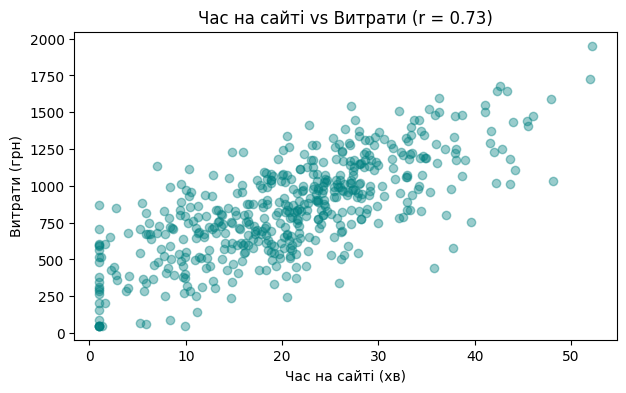

In [133]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.2e}")

plt.figure(figsize=(7,4))
plt.scatter(df["session_min"], df["spend"], alpha=0.4, color="teal")
plt.xlabel("Час на сайті (хв)")
plt.ylabel("Витрати (грн)")
plt.title(f"Час на сайті vs Витрати (r = {r:.2f})")
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Звʼязок прямий. Коефіцієнт r = 0.732 — додатний, тобто чим більше часу людина проводить на сайті, тим більші в неї витрати (і навпаки).
Сила звʼязку. За шкалою Чеддока значення 0.7–0.9 вважається сильним звʼязком. Тобто 0.732 — це досить сильна залежність, не слабка і не помірна.
Значущість. p-значення = 4.05e-85 — це число, яке набагато менше за стандартний поріг 0.05 (фактично майже нуль). Це означає, що звʼязок статистично значущий — тобто з дуже високою ймовірністю він не випадковий, а реально існує в даних.
А чи це причинно-наслідковий звʼязок?
Ні, стверджувати це не можна. Кореляція показує лише, що дві змінні повʼязані між собою (рухаються в одному напрямку), але вона не доводить, що одна змінна спричиняє іншу.    
Тут є кілька можливих пояснень:    

Можливо, час на сайті дійсно впливає на витрати (людина довше дивиться товари — більше купує).    
Але може бути і навпаки: людина, яка вже планує купити більше, просто довше переглядає сайт, щоб обрати потрібні товари.    
Або є третя прихована змінна, яка впливає на обидва показники одразу. Наприклад, рівень зацікавленості людини в покупках, наявність вільного часу чи сезонні акції — вони можуть одночасно "тягнути вгору" і час на сайті, і суму витрат.    

 Між часом на сайті та витратами є сильний і статистично значущий прямий звʼязок, але на основі лише кореляції не можна стверджувати, що саме час на сайті є причиною більших витрат. Для висновку про причинність потрібні додаткові дослідження (наприклад, експеримент A/B-тест, де штучно змінюють час на сайті і дивляться, чи зміняться витрати).    

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

Коефіцієнт кореляції r: -0.042
p-значення: 3.51e-01


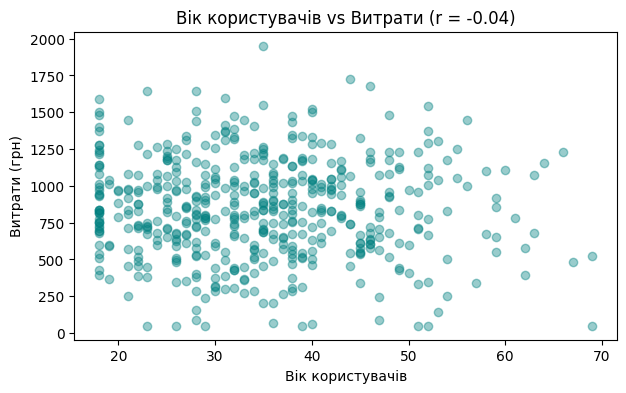

In [134]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.2e}")

plt.figure(figsize=(7,4))
plt.scatter(df["age"], df["spend"], alpha=0.4, color="teal")
plt.xlabel("Вік користувачів")
plt.ylabel("Витрати (грн)")
plt.title(f"Вік користувачів vs Витрати (r = {r:.2f})")
plt.show()

#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Звʼязок зворотний (мінус перед r означає, що зі збільшенням віку витрати трохи зменшуються), але дивитись тут особливо нема на що, бо звʼязку по суті немає.
Сила звʼязку. r = -0.042 — це майже нуль. За шкалою Чеддока це навіть не "дуже слабкий", а просто відсутність лінійного звʼязку. Тобто вік практично ніяк не повʼязаний з витратами.    
Значущість. p-значення = 0.351 — це набагато більше за поріг 0.05. Це означає, що звʼязок статистично НЕзначущий. Тобто ми не можемо навіть стверджувати, що ця слабенька кореляція (-0.042) реальна — вона цілком може бути випадковістю в даних, а не справжньою закономірністю в генеральній сукупності.    
Між віком користувачів та їхніми витратами не виявлено статистично значущого звʼязку (r = -0.042, p = 0.351). Оскільки p-значення набагато більше за 0.05, немає підстав вважати, що вік впливає на суму витрат — у даних користувачі різного віку витрачають приблизно однаково.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [135]:
# Завдання 14:
ab["group"].value_counts()

,count
group,
A,4000
B,4000


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [136]:
# Завдання 15:
ab.groupby('group')['converted'].mean()

,converted
group,
A,0.101
B,0.119


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Група B показує вищу конверсію (0.119 проти 0.101 у групи A).
Але це не означає, що версія B точно краща. Ось чому:
1. Це лише вибірка, а не вся популяція користувачів.        
Ми бачили поведінку лише частини користувачів (тих, хто потрапив у тест), а не всіх можливих відвідувачів сайту. Інша вибірка могла б дати трохи інші цифри — навіть якби насправді обидві версії були однаково хороші.    

2. Різниця може пояснюватись випадковістю.    
Уявіть, що ви підкидаєте монетку 100 разів — навіть чесна монетка рідко дає рівно 50/50. Так само різниця 0.101 vs 0.119 може бути просто природним "шумом" вибірки, а не реальним ефектом версії B.    

3. Нам потрібна оцінка ймовірності випадковості.    
Статистичний тест (наприклад, z-тест для пропорцій або хі-квадрат) дозволяє відповісти на питання: "Якби насправді конверсія A і B була однаковою, наскільки ймовірно було б побачити таку різницю просто випадково?"
Якщо ця ймовірність (p-value) дуже мала — ми можемо з більшою впевненістю сказати, що різниця реальна, а не випадкова.    

Якщо ймовірність висока — різниця може бути просто шумом, і робити висновки рано.     
Висновок: самих чисел 0.101 і 0.119 недостатньо — потрібен тест, який врахує розмір вибірки та природну варіативність даних, щоб зрозуміти, чи різниця статистично значуща.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**    
- `H₀` (нульова гіпотеза): Конверсія в групі A і групі B однакова. Різниця, яку ми бачимо (0.101 проти 0.119), пояснюється випадковістю вибірки, а не реальним впливом версії B.    
- `H₁` (альтернативна гіпотеза): Конверсія в групі A і групі B відрізняється. Версія B реально впливає на конверсію (підвищує або знижує її), і ця різниця не пояснюється лише випадковістю.    

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [137]:
# Завдання 16:
import pandas as pd
from scipy.stats import chi2_contingency

ab = pd.read_csv('ab_test.csv')

# Таблиця спряженості
contingency_table = pd.crosstab(ab['group'], ab['converted'])
print(contingency_table)

# Тест хі-квадрат
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")

converted     0    1
group               
A          3596  404
B          3524  476
Chi2: 6.4364
p-value: 0.011180


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

**Висновок:**    
Так, різниця статистично значуща при α = 0.05: p-значення = 0.0112 < 0.05, тому відхиляємо H₀ і приймаємо H₁ — конверсія в групах A і B справді відрізняється, і ця різниця не пояснюється випадковістю.     

**Фінальна рекомендація для продуктової команди:**    
Результати A/B-тесту показують статистично значуще покращення конверсії у версії B порівняно з версією A (11.9% проти 10.1%, p = 0.011), що відповідає приросту приблизно на 18% відносно базового рівня. Враховуючи, що ймовірність випадкового характеру цієї різниці становить лише ~1.1%, рекомендую впровадити версію B як основну. Водночас варто врахувати практичну значущість ефекту з точки зору бізнесу (наприклад, як приріст 1.8 п.п. конверсії транслюється у додатковий дохід чи кількість клієнтів) та переконатися, що тест тривав достатньо довго і вибірка не містить сезонних викривлень, перш ніж масштабувати зміну на всіх користувачів.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Я оберу ANOVA (однофакторний дисперсійний аналіз).
Чому саме він, а не t-тест чи хі-квадрат:

t-тест порівнює середні значення тільки між двома групами, а тут у нас три канали залучення — тож t-тест не підходить.
хі-квадрат використовується для категоріальних змінних (наприклад, "канал" і "купив/не купив"), а тут ми порівнюємо числову змінну (вік) — тож хі-квадрат теж не той інструмент.
ANOVA якраз створена для того, щоб порівнювати середні значення числової змінної (вік) одразу між трьома і більше групами (канали залучення), і перевірити, чи є різниця між ними статистично значущою, чи ні.

Тобто ANOVA дає відповідь на питання: "Чи відрізняється середній вік клієнтів хоча б в одному з каналів від інших, чи всі три канали приблизно однакові за віком?"

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [138]:
# Завдання 17:
groups = df.groupby('channel')['age'].apply(list)

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-статистика: {f_stat:.4f}")
print(f"p-значення: {p_value:.6f}")

F-статистика: 0.5989
p-значення: 0.549838


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Оскільки p-значення (0.55) набагато більше за 0.05, ми не відхиляємо H₀. Це означає, що статистично значущої різниці в середньому віці клієнтів між трьома каналами залучення (Реклама, Органіка, Соцмережі) не виявлено. Канал, через який прийшов клієнт, не пов'язаний з його віком — спостережена різниця в середніх (34.2–35.4 років) пояснюється звичайною випадковістю вибірки, а не реальною відмінністю між каналами.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тут підходить одновибірковий t-тест (one-sample t-test).    
Чому саме він:    

Ми порівнюємо середнє значення однієї числової змінної (витрати клієнтів) з конкретним фіксованим числом (900 грн), яке стверджує маркетолог — а не порівнюємо дві чи більше груп між собою.    
ANOVA і двовибірковий t-тест тут не підходять, бо вони порівнюють групи між собою, а нам треба порівняти середнє по вибірці з заздалегідь заданим значенням.
Хі-квадрат теж не годиться, бо витрати — це числова (неперервна) змінна, а не категоріальна.    

Тобто one-sample t-test дасть відповідь на питання: "Чи відрізняється середнє значення витрат у нашій вибірці клієнтів від заявлених маркетологом 900 грн, чи ця різниця може пояснюватись випадковістю вибірки?"



#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [142]:
# Завдання 18:
from scipy import stats

t_stat, p_value = stats.ttest_1samp(df['spend'], 900)
print(f"t-статистика: {t_stat:.4f}")
print(f"p-значення: {p_value:.6f}")

t-статистика: -3.6870
p-значення: 0.000252


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

p-значення = 0.00025, що набагато менше за 0.05.    
**Це означає:** ми відхиляємо H₀.    
 Середні витрати клієнтів статистично значуще відрізняються від 900 грн — і оскільки t-статистика від'ємна, а фактичне середнє (845.02 грн) нижче за заявлене, можна стверджувати, що реальні середні витрати клієнтів нижчі, ніж стверджує маркетолог.    
**Простими словами:** твердження маркетолога про середні витрати в 900 грн не підтверджується даними — насправді клієнти в середньому витрачають менше (близько 845 грн), і ця різниця занадто велика, щоб пояснити її простою випадковістю вибірки.    

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
Тут підходить тест хі-квадрат на незалежність (chi-square test of independence).
Чому саме він:

І country, і device — це категоріальні змінні (не числові), тому t-тест і ANOVA тут не підходять (вони працюють з числовими змінними типу вік чи витрати).
Хі-квадрат якраз створений для перевірки, чи пов'язані між собою дві категоріальні змінні, чи вони незалежні одна від одної.

H₀: країна клієнта і тип пристрою — незалежні (немає зв'язку).

H₁: країна клієнта і тип пристрою — пов'язані (є зв'язок).

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [143]:
# Завдання 19:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['country'], df['device'])
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2:.4f}")
print(f"p-значення: {p_value:.6f}")

device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166
Chi2: 1.2067
p-значення: 0.546989


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

p-значення (0.55) набагато більше за 0.05, тому ми не відхиляємо H₀. Статистично значущого зв'язку між країною клієнта і типом пристрою не виявлено — у всіх трьох країнах клієнти користуються Desktop і Mobile приблизно в однаковій пропорції (різниця в цифрах пояснюється випадковістю вибірки).

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тут підходить кореляція Пірсона (Pearson correlation).
Чому саме вона:

І age, і session_min — це числові (неперервні) змінні, тому хі-квадрат не підходить (він для категоріальних даних).
ANOVA і t-тест тут теж не годяться, бо вони порівнюють середні значення між групами, а в нас немає окремих груп — є дві числові змінні, і нам треба перевірити, чи змінюються вони разом (наприклад, чи зі збільшенням віку зростає чи спадає час на сайті).
Кореляція Пірсона якраз вимірює силу та напрямок лінійного зв'язку між двома числовими змінними.

H₀: кореляції між віком і часом на сайті немає (r = 0).

H₁: кореляція між віком і часом на сайті існує (r ≠ 0).

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [144]:
# Завдання 20:
from scipy import stats

r, p_value = stats.pearsonr(df['age'], df['session_min'])
print(f"Коефіцієнт кореляції r: {r:.4f}")
print(f"p-значення: {p_value:.6f}")

Коефіцієнт кореляції r: -0.0119
p-значення: 0.789823


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Опис зв'язку:

Напрямок: коефіцієнт r від'ємний (-0.0119), що формально вказує на дуже слабкий обернений зв'язок (зі збільшенням віку час на сайті трохи знижується) — але це значення настільки близьке до нуля, що про напрямок навіть говорити не варто.
Сила: r = -0.0119 — це практично відсутність зв'язку. Для порівняння: значення r ближче до ±1 означають сильний зв'язок, а ближче до 0 — слабкий або відсутній. Наше значення майже дорівнює нулю, тобто зв'язку між віком і часом на сайті фактично немає.    
Значущість: p-значення = 0.79, що набагато більше за 0.05 → зв'язок статистично незначущий. Ми не відхиляємо H₀.

`Загальний висновок:` вік клієнта і час, проведений на сайті, не пов'язані між собою — ні напрямок, ні сила кореляції не дають підстав стверджувати, що один показник якось залежить від іншого. Молодші й старші клієнти в середньому проводять на сайті приблизно однаковий час.    

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
